# Document Clustering — Data Cleaning & Feature Engineering

This notebook takes the raw 20 Newsgroups text, applies a text-cleaning pipeline, removes near-empty documents and duplicates, and saves the cleaned dataset to `data/newsgroups.csv` for downstream modelling.

## 1. Imports & Load Raw Data

We fetch the six-category newsgroups subset using the same `load_newsgroups` helper as in notebook 01, ensuring identical shuffle and random state.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
import sys, os
sys.path.insert(0, '.')
from utils import load_newsgroups, clean_text
sns.set_style('whitegrid')
%matplotlib inline

CATEGORIES = [
    'rec.sport.hockey',
    'sci.space',
    'talk.politics.mideast',
    'comp.graphics',
    'rec.autos',
    'sci.med',
]
df = load_newsgroups(CATEGORIES)
print('Raw shape:', df.shape)
df.head(3)

Raw shape: (5879, 2)


,text,true_category
0,This is such Bullshit. Deir Yassin was an unp...,talk.politics.mideast
1,"Check out the shocks where they mount,...",rec.autos
2,"While in grad school, I remember a biochemistr...",sci.med


## 2. Inspect Raw Text

We look at a few raw documents before cleaning to understand what artefacts need to be removed — punctuation, digits, residual e-mail fragments, and mixed-case tokens are the main sources of noise.

In [2]:
print('=== Sample raw document ===')
print(df['text'].iloc[0][:800])

=== Sample raw document ===
This is such Bullshit.  Deir Yassin was an unprovoked attack on
the part of the Jews, and a massacre defines it best in my
opinion.  The village of Deir Yassin had had a pact with the
Jews, a peace pact, but the Irgun purposely broke this
agreement in order to scare off the Palestinians.  I might
grant that this village housed armed Arabs [I doubt it] but
nothing in the archives and available literature indicates that
this was a motivating force amongst the Irgun.  The Deir Yassin
MASSACRE was part of an over all strategy to intimidate the
Palestinians to flee the Jewish Homeland.,...and contrary to
your belief, many civilians were killed.  Deir Yassin was later
advertized by the very Jews who perpetrated it because it was
useful in getting many Palestinians to leave.  The Palestinians
wer


## 3. Apply Text Cleaning

**Cleaning strategy:**

1. **Lowercase** — normalises token forms (e.g. *NASA* → *nasa*).
2. **Remove URLs** — residual web links add noise without topic signal.
3. **Strip punctuation & digits** — keeps only a–z letters; numbers rarely carry discriminative value in newsgroup text.
4. **Collapse whitespace** — simplifies downstream tokenisation.

Stop-word removal is deferred to the TF-IDF vectoriser in notebook 03, where `stop_words='english'` is set explicitly.

In [3]:
df['text_clean'] = df['text'].apply(clean_text)
print('Cleaning complete.')
print('Sample cleaned document:')
print(df['text_clean'].iloc[0][:400])

Cleaning complete.
Sample cleaned document:
this is such bullshit deir yassin was an unprovoked attack on the part of the jews and a massacre defines it best in my opinion the village of deir yassin had had a pact with the jews a peace pact but the irgun purposely broke this agreement in order to scare off the palestinians i might grant that this village housed armed arabs i doubt it but nothing in the archives and available literature indi


## 4. Before / After Cleaning Examples

Comparing the raw and cleaned versions confirms that URLs, punctuation, and digits have been removed while the topical vocabulary is intact.

In [4]:
for i in [0, 5, 10]:
    print(f'\n--- Document {i} ---')
    print('BEFORE:', df['text'].iloc[i][:200].replace('\n', ' '))
    print('AFTER :', df['text_clean'].iloc[i][:200])


--- Document 0 ---
BEFORE: This is such Bullshit.  Deir Yassin was an unprovoked attack on the part of the Jews, and a massacre defines it best in my opinion.  The village of Deir Yassin had had a pact with the Jews, a peace pa
AFTER : this is such bullshit deir yassin was an unprovoked attack on the part of the jews and a massacre defines it best in my opinion the village of deir yassin had had a pact with the jews a peace pact but

--- Document 5 ---
BEFORE:  The DeLorean had the yucky PRV V6 engine. A joint-venture between Peugout (note  spelling), Renault and Volvo. PRV. This engine is a *MIGHTY BORING* piece of junk with approx 140hp. Doesn't like revs
AFTER : the delorean had the yucky prv v engine a joint venture between peugout note spelling renault and volvo prv this engine is a mighty boring piece of junk with approx hp doesn t like revs at all if you 

--- Document 10 ---
BEFORE: Well, we got some responses and are doing some interviews with interesting responders. However,

## 5. Remove Short, Empty, and Duplicate Documents

Documents with fewer than 20 characters after cleaning carry almost no topical signal — they typically consist of a single word or a short phrase. Exact duplicates (same cleaned text) are also removed to avoid inflating any cluster with repeated content.

In [5]:
print('Documents before filtering:', len(df))
# Drop very short
df = df[df['text_clean'].str.len() >= 20].copy()
print('After removing docs < 20 chars:', len(df))
# Drop exact duplicates on cleaned text
df = df.drop_duplicates(subset='text_clean').copy()
print('After removing duplicates:', len(df))
# Replace original text column with cleaned version
df = df[['text_clean', 'true_category']].rename(columns={'text_clean': 'text'})
df = df.reset_index(drop=True)
print('\nFinal shape:', df.shape)

Documents before filtering: 5879


After removing docs < 20 chars: 5650


After removing duplicates: 5631

Final shape: (5631, 2)


## 6. Word Count Distribution After Cleaning

After cleaning we add a `word_count` column and re-examine the distribution. The cleaning step typically reduces word counts slightly (removed digits, punctuation-adjacent tokens) but should not dramatically alter the shape.

count     5631.0
mean       207.6
std        586.2
min          4.0
25%         46.0
50%         89.0
75%        179.0
max      11420.0
Name: word_count, dtype: float64


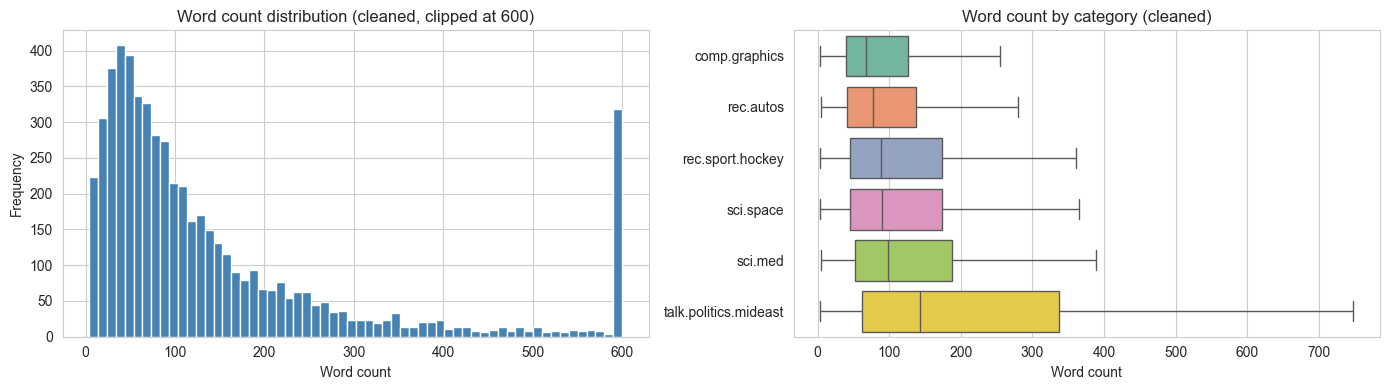

In [6]:
df['word_count'] = df['text'].str.split().str.len()
print(df['word_count'].describe().round(1))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['word_count'].clip(upper=600), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Word count distribution (cleaned, clipped at 600)')
axes[0].set_xlabel('Word count'); axes[0].set_ylabel('Frequency')
order = df.groupby('true_category')['word_count'].median().sort_values().index
sns.boxplot(data=df, x='word_count', y='true_category', order=order,
            palette='Set2', ax=axes[1], showfliers=False)
axes[1].set_title('Word count by category (cleaned)')
axes[1].set_xlabel('Word count'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

In [7]:
print('Category counts after cleaning:')
print(df['true_category'].value_counts())

Category counts after cleaning:


true_category
rec.sport.hockey         967
sci.med                  950
sci.space                945
comp.graphics            943
rec.autos                920
talk.politics.mideast    906
Name: count, dtype: int64


## 7. Save Cleaned Dataset

We save the cleaned DataFrame to `data/newsgroups.csv`. Notebook 03 will read this file directly for TF-IDF vectorisation and clustering. The `word_count` column is retained as a lightweight diagnostic feature.

In [8]:
os.makedirs('data', exist_ok=True)
out_path = 'data/newsgroups.csv'
df.to_csv(out_path, index=False)
print(f'Saved {len(df)} rows to {out_path}')
print(df.dtypes)
df.head()

Saved 5631 rows to data/newsgroups.csv


text             object
true_category    object
word_count        int64
dtype: object


,text,true_category,word_count
0,this is such bullshit deir yassin was an unpro...,talk.politics.mideast,192
1,check out the shocks where they mount at both ...,rec.autos,67
2,while in grad school i remember a biochemistry...,sci.med,141
3,from center for policy research cpr subject un...,talk.politics.mideast,914
4,it seems sad that people lose all perspective ...,rec.autos,250
